In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, i1, k0, k1
import CoolProp.CoolProp as CP
from scipy.interpolate import interp1d
from tabulate import tabulate
import pandas as pd
from IPython.display import display # Importamos display para Jupyter
from PIL import Image
import os


# Intercambiador a contraflujo con recirculación

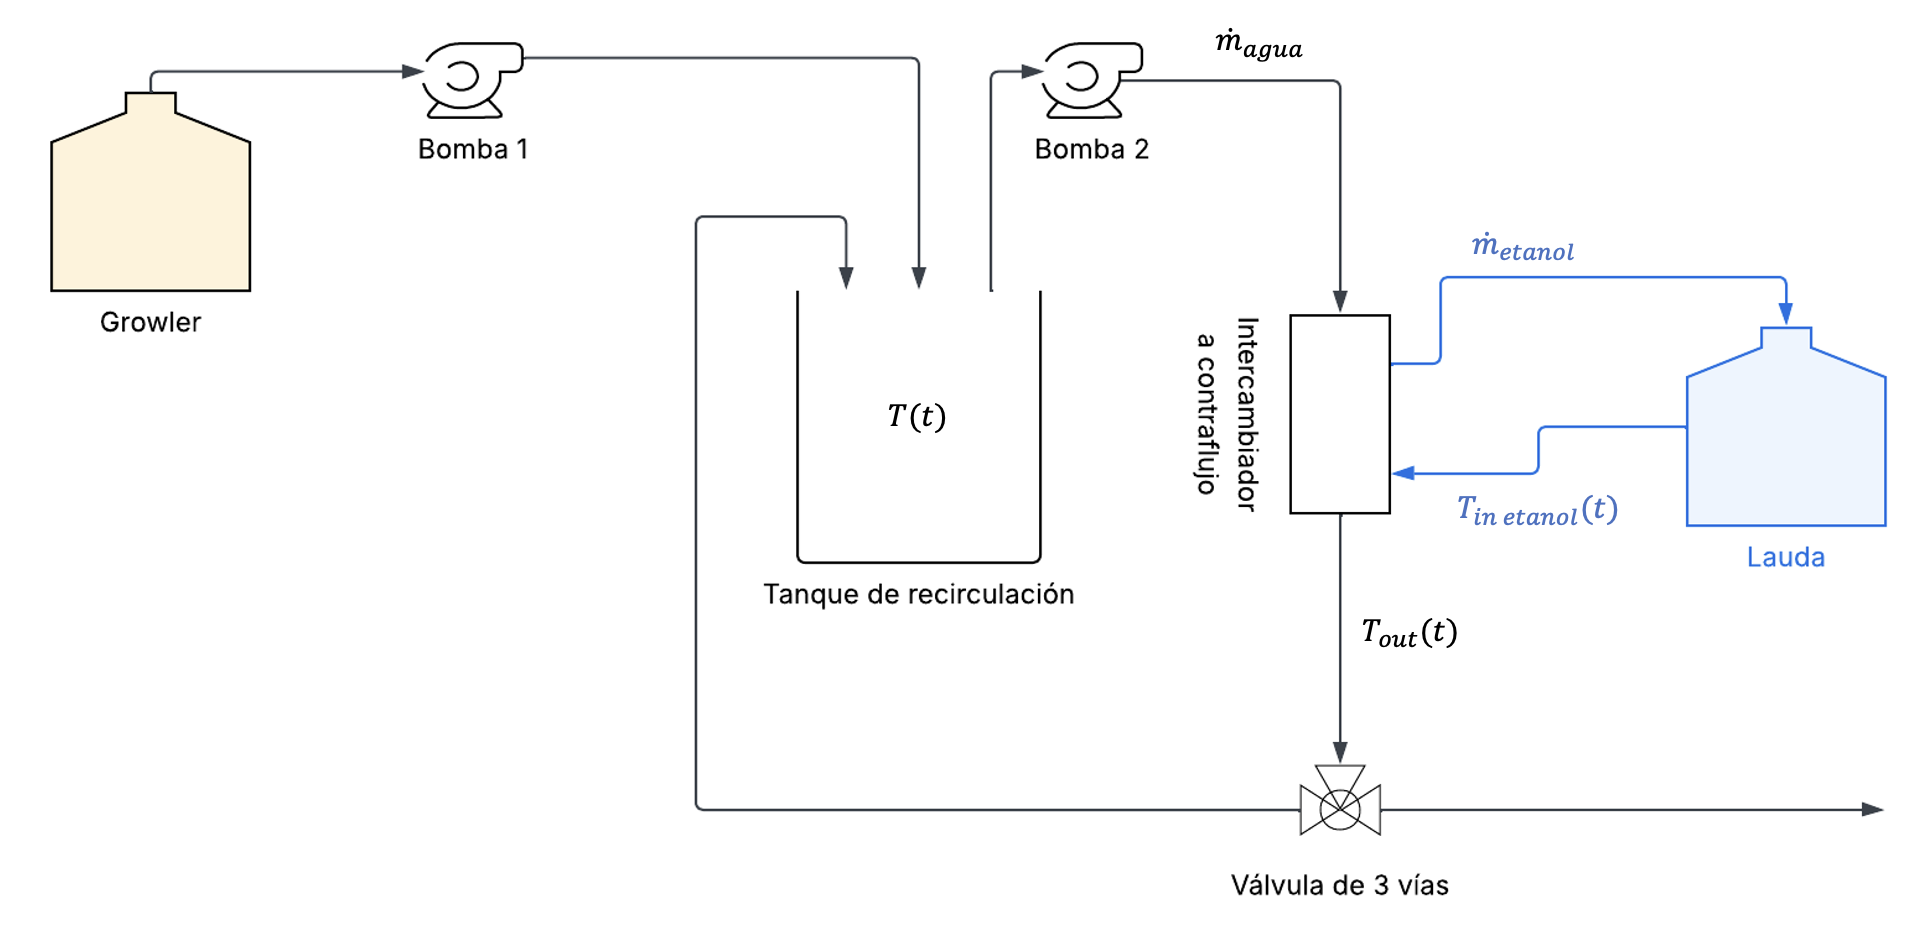

In [38]:
path_photo = os.path.join(os.getcwd(), 'fotos', 'diagrama_recirculacion.png')  # Asegúrate de que 'photo.jpg' esté en el mismo directorio que este script
if os.path.exists(path_photo):
    img = Image.open(path_photo)
    display(img)  # Muestra la imagen en Jupyter
else:    
    print(f"No se encontró la imagen en la ruta: {path_photo}")

Se toman los siguientes supuestos:
- La temperatura a la que sale el agua del tanque de circulación es la misma que la temperatura dentro del tanque
- La válvula de 3 vías se encuentra accionada de forma de que todo el caudal se recircula
- La bomba 1 no se encuentra en funcionamiento

Haciendo un balance de energía para el tanque de recirculación, se tiene:

$$
\dot{m}_{agua} c_{p} (T(t) - T_{out}(t)) = -\rho V c_p \frac{dT}{dt}
$$

Ahora, analizando el intercambiador de calor, se tiene que:

$$
\dot{Q}_{Hx} = \dot{m}_{agua} c_p (T(t) - T_{out}(t))
$$

El calor del intercambiador de calor puede ser calculado a partir de la eficiencia del intercambiador de calor y del calor máximo

$$
\dot{Q}_{Hx} = \varepsilon \dot{Q}_{max} = \varepsilon C_{min} (T(t) - T_{in,etanol})
$$

De esta forma, se tiene la siguiente EDO:

$$
\varepsilon C_{min} (T(t) - T_{in,etanol}) = -\rho V c_p \frac{dT}{dt}
$$

La cual tiene la siguiente solución considerando como condición inicial $T(0) = T_0$.

$$
T(t) = T_{in,etanol} + (T_0 - T_{in,etanol}) \cdot e^{(\frac{-\varepsilon C_{min}}{\rho V c_p }t)}
$$

Recordemos que la efectividad de un intercambiador a contraflujo se calcula a partir de la siguiente ecuación:

$$
\varepsilon = \frac{1 - e^{-NTU(1-C_r)}}{1 - C_re^{-NTU(1-C_r)}}
$$
 
Donde $NTU = \frac{UA}{C_{min}}$. El valor $UA$ se calcula de la siguiente forma:

$$
\frac{1}{UA} = \frac{1}{h_{agua}A_{agua}} + \frac{\ln(D_o/D_i)}{2\pi L k_{cobre}} + \frac{1}{h_{etanol}A_{etanol}}
$$

Donde $A_{agua}$ es el área del manto interior del tubo que contiene al agua, $A_{etanol}$ es el área del manto exterior del tubo que contiene al agua. El coeficiente de convección $h_{agua}$ se calcula a partir del númer de Nusselt para un tubo circular a calor constante, mientras que $h_{etanol}$ se calcula a partir del número de Nusselt para el flujo por una sección anular con calor constante

## Análisis Térmico del intercambiador de calor

In [39]:
class IntercambiadorContraflujo:

    '''Clase para modelar un intercambiador de calor de contraflujo.
    Se asumirá que el fluido caliente va por el tubo, y el frío por la sección anular'''

    def __init__(self, Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, V_vaso):

        '''Recibe:
        Q_hot: Caudal volumétrico del fluido caliente (m^3/s)
        Q_cold: Caudal volumétrico del fluido frío (m^3/s)
        T_in_hot: Temperatura de entrada del fluido caliente (K)
        T_in_cold: Temperatura de entrada del fluido frío (K)
        D_in_hot: Diámetro interno del tubo del fluido caliente (m)
        D_out_hot: Diámetro externo del tubo del fluido caliente (m)
        D_in_cold: Diámetro interno del tubo del fluido frío (m)
        D_out_cold: Diámetro externo del tubo del fluido frío (m)
        Length: Longitud del intercambiador (m)
        k_tube: Conductividad térmica del material del tubo (W/m·K)'''

        self.Q_hot = Q_hot
        self.Q_cold = Q_cold
        self.T_in_hot = T_in_hot
        self.T_in_cold = T_in_cold
        self.D_in_hot = D_in_hot
        self.D_out_hot = D_out_hot
        self.D_in_cold = D_in_cold
        self.D_out_cold = D_out_cold
        self.Length = Length
        self.k_tube = k_tube
        self.P = 101325  # Presión atmosférica en Pa
        self.cold_fluid = 'Ethanol'
        self.cold_fluid_concentration = 0.01 # Concentración de etanol en el agua (1% etanol)
        self.V_vaso = V_vaso
        self.T_0_vaso = T_in_hot


    def calcular_propiedades_agua(self):
        self.rho_hot = CP.PropsSI('D', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.cp_hot = CP.PropsSI('C', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.mu_hot = CP.PropsSI('V', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.k_hot = CP.PropsSI('L', 'T', self.T_in_hot, 'P', self.P, 'Water')  
        self.beta_hot = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.nu_hot = self.mu_hot / self.rho_hot
        self.m_dot_hot = self.rho_hot * self.Q_hot
        self.Re_hot = (4 * self.m_dot_hot) / (np.pi * (self.D_in_hot) * self.mu_hot)
        self.Pr_hot = self.cp_hot * self.mu_hot / self.k_hot

    def calcular_propiedades_solucion_etanol(self):

        vol_water = 1 - self.cold_fluid_concentration
        vol_ethanol = self.cold_fluid_concentration

        # ------------------------- Densidad -------------------------- 
        rho_etanol =  CP.PropsSI('D', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        rho_agua = CP.PropsSI('D', 'T', self.T_in_cold, 'P', self.P, 'Water')
        mass_etanol = rho_etanol * vol_ethanol
        mass_agua = rho_agua * vol_water
        mass_total = mass_etanol + mass_agua
        mass_frac_water = mass_agua / mass_total
        mass_frac_ethanol = mass_etanol / mass_total
        self.rho_cold = (mass_etanol + mass_agua) / (vol_ethanol + vol_water)

        # ------------------------- Capacidad calorífica --------------------------
        cp_etanol = CP.PropsSI('C', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        cp_agua = CP.PropsSI('C', 'T', self.T_in_cold, 'P', self.P, 'Water')
        self.cp_cold = (cp_etanol * mass_etanol + cp_agua * mass_agua) / (mass_etanol + mass_agua)

        # ------------------------- Viscosidad Dinámica --------------------------
        mu_etanol = CP.PropsSI('V', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        mu_agua = CP.PropsSI('V', 'T', self.T_in_cold, 'P', self.P, 'Water')
        self.mu_cold = float(np.exp(vol_water * np.log(mu_agua) + vol_ethanol * np.log(mu_etanol)))

        # ------------------------- Conductividad Térmica --------------------------
        k_etanol = CP.PropsSI('L', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        k_agua = CP.PropsSI('L', 'T', self.T_in_cold, 'P', self.P, 'Water')
        self.k_cold = mass_frac_water * k_agua + mass_frac_ethanol * k_etanol

        # ------------------------- Coeficiente de expansión isobárica --------------------------
        self.beta_cold = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)


        # De aquí en adelante sigue normal
        self.nu_cold = self.mu_cold / self.rho_cold
        self.m_dot_cold = self.rho_cold * self.Q_cold
        self.D_h = self.D_in_cold - self.D_out_hot
        self.Re_cold = (4 * self.m_dot_cold) / (np.pi * (self.D_h) * self.mu_cold)
        self.Pr_cold = self.cp_cold * self.mu_cold / self.k_cold

        self.C_min = min(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_max = max(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_ratio = self.C_min / self.C_max

    def conveccion_tubo_interior(self):

        '''Calculamos el coeficiente de convección para el 
        fluido caliente, que va por el tubo interior.'''

        self.A_hot = np.pi * self.D_in_hot * self.Length

        if self.Re_hot < 2300:
            self.Nu_hot = 4.36
        else:
            self.Nu_hot = 0.023 * (self.Re_hot ** 0.8) * (self.Pr_hot ** 0.3)

        self.h_hot = self.Nu_hot * self.k_hot / self.D_in_hot

    def conveccion_seccion_anular(self):
        
        '''Calculamos el coeficiente de convección para el 
        fluido frío, que va por la sección anular.'''

        self.A_cold = np.pi * (self.D_out_hot * self.Length)

        self.tabla_8_3 = {
            "Di_Do": [0.05, 0.10, 0.20, 0.40, 0.60, 0.80],
            "Nu_ii": [17.81, 11.91, 8.499, 6.583, 5.912, 5.58],
            "Nu_oo": [4.792, 4.834, 4.833, 4.979, 5.099, 5.24]
        }

        Di_Do = self.D_out_hot / self.D_in_cold

        # Creamos las funciones de interpolación
        # 'kind=cubic' para curvas suaves o 'linear' para mayor seguridad con pocos datos
        interp_Nu_ii = interp1d(self.tabla_8_3["Di_Do"], self.tabla_8_3["Nu_ii"], kind='cubic', fill_value="extrapolate")
        # interp_Nu_oo = interp1d(self.tabla_8_3["Di_Do"], self.tabla_8_3["Nu_oo"], kind='cubic', fill_value="extrapolate")

        # Calculamos los Nusselt específicos para tu geometría
        self.Nu_ii_interp = float(interp_Nu_ii(Di_Do))
        # self.Nu_oo_interp = float(interp_Nu_oo(Di_Do))

        if self.Re_cold < 2300:
            factor_ajuste = 1.0
        else:
            factor_ajuste = 0.86 * ((self.D_out_hot / self.D_in_cold) ** (-0.16))

        self.h_cold = factor_ajuste * self.Nu_ii_interp * self.k_cold / self.D_h

    def calcular_UA(self):

        '''Calculamos el producto UA para cada fluido y el total.'''

        self.R_hot = 1 / (self.h_hot * self.A_hot)
        self.R_cold = 1 / (self.h_cold * self.A_cold)
        self.R_conduction = np.log(self.D_out_hot / self.D_in_hot) / (2 * np.pi * self.k_tube * self.Length)

        # Para intercambiadores en contraflujo, el UA total se calcula como:
        self.UA_total = 1 / (self.R_hot + self.R_cold + self.R_conduction)

    def calcular_efectividad(self):
        
        '''Calculamos la efectividad del intercambiador de calor.'''

        self.NTU = self.UA_total / self.C_min

        exp_term = np.exp(-self.NTU * (1 - self.C_ratio))

        if self.C_min == self.C_max:
            self.efectividad = self.NTU / (1 + self.NTU)
        else:
            self.efectividad = (1 - exp_term) / (1 - (self.C_ratio * exp_term))

    def calcular_temperaturas_salida(self):
        
        '''Calculamos las temperaturas de salida de ambos fluidos.'''

        self.Q_max = self.C_min * (self.T_in_hot - self.T_in_cold)
        self.Q_hx = self.efectividad * self.Q_max

        self.T_out_hot = self.T_in_hot - (self.Q_hx / (self.m_dot_hot * self.cp_hot))
        self.T_out_cold = self.T_in_cold + (self.Q_hx / (self.m_dot_cold * self.cp_cold))

    def grafico_intercambiador(self):
        
        '''Generamos un gráfico del intercambiador de calor.'''

        plt.figure(figsize=(10, 6))
        plt.plot([0, self.Length], [self.T_in_hot - 273.15, self.T_out_hot - 273.15], label='Agua', marker='o')
        plt.plot([0, self.Length], [self.T_in_cold - 273.15, self.T_out_cold - 273.15], label='Etanol', marker='o')
        plt.xlabel('Longitud del Intercambiador (m)')
        plt.ylabel('Temperatura (K)')
        plt.title('Perfil de Temperatura en el Intercambiador de Calor')
        plt.legend()
        plt.grid()
        plt.show()

    def edo_temperatura_vaso(self):
        self.t_values = np.linspace(0, 1800, 100)  # Simulamos por 30 min
        rho_vaso = CP.PropsSI('D', 'T', self.T_in_hot, 'P', self.P, 'Water')
        cp_vaso = CP.PropsSI('C', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.tau = (rho_vaso * self.V_vaso * cp_vaso) / (self.efectividad * self.C_min)

        self.T_t = self.T_in_cold + (self.T_0_vaso - self.T_in_cold) * np.exp(- self.t_values / self.tau)
        self

    def calcular_tiempo_enfriamiento(self):
        T_target = self.T_in_cold + 0.5
        self.t_enfriamiento = -self.tau * np.log((T_target - self.T_in_cold) / (self.T_0_vaso - self.T_in_cold))


    def resumen(self):

        '''Imprimimos un resumen de los resultados obtenidos.'''

        data = [
            ['T_in_hot (K)', self.T_in_hot - 273.15],
            ['T_out_hot (K)', self.T_out_hot - 273.15],
            ['T_in_cold (K)', self.T_in_cold - 273.15],
            ['T_out_cold (K)', self.T_out_cold - 273.15],
            ['Efectividad', self.efectividad],
            ['UA_total (W/K)', self.UA_total],
            ['Re_hot', self.Re_hot],
            ['Re_cold', self.Re_cold],
            ['h_hot (W/m^2K)', self.h_hot],
            ['h_cold (W/m^2K)', self.h_cold]
        ]
        headers = ['Parámetro', 'Valor']
        print(tabulate(data, headers=headers, tablefmt="grid"))

    def grafico_T_t(self):
        '''Generamos un gráfico de la temperatura del vaso en función del tiempo.'''

        plt.figure(figsize=(10, 6))
        plt.plot(self.t_values / 60, self.T_t - 273.15, label=rf'Temperatura del Vaso {self.V_vaso * 1e6:.0f} mL', marker='o')
        plt.xlabel('Tiempo (min)')
        plt.ylabel('Temperatura (°C)')
        plt.title('Enfriamiento del Vaso con el Intercambiador de Calor')
        plt.legend()
        plt.grid()
        plt.show()

    def ejecutar(self):
        
        '''Ejecutamos todos los cálculos en orden.'''

        self.calcular_propiedades_agua()
        self.calcular_propiedades_solucion_etanol()
        self.conveccion_tubo_interior()
        self.conveccion_seccion_anular()
        self.calcular_UA()
        self.calcular_efectividad()
        self.calcular_temperaturas_salida()
        self.edo_temperatura_vaso()
        self.calcular_tiempo_enfriamiento()
        # self.resumen()
        # self.grafico_intercambiador()


In [40]:
Q_cold = 15 * 0.001 / 60 # (pasamos de L/min a m³/s)
T_in_hot = 20 + 273.15  # Temperatura de entrada del fluido caliente (K)
T_in_cold = 4 + 273.15  # Temperatura de entrada del fluido frío (K)
D_in_hot = (6.35 - 0.76) / 1000  # Diámetro interno del tubo del fluido caliente (m)
D_out_hot = 6.35 / 1000  # Diámetro externo del tubo del fluido caliente (m)
Length = 0.3 # Longitud del intercambiador (m)
k_tube = 45  # Conductividad térmica del material del tubo (W/m·K)

# ---------------- Parámetros a optimizar ----------------

possible_water_flow_rates = np.array([240, 300, 400, 600, 800, 1200, 1800]) * 0.001 / 3600  # Caudales comerciales de agua en m³/s

# Diámetros comerciales de PVC
# https://catalogo.extension.cchc.cl/documentos/documentos/16094.pdf
possible_cold_inner_diameters = np.array([8, 10, 13.6, 17, 22, 27.2, 34, 42.6, 53.6, 63.8, 76.6, 93.6, 106.4, 119.2]) * 1e-3
possible_cold_outer_diameters = np.array([10, 12, 16, 20, 25, 32, 40, 50, 63, 75, 90, 110, 125, 140]) * 1e-3

possible_volumes = np.array([200, 300, 400, 500, 600, 700, 800, 900, 1000]) * 1e-6  # Volúmenes comerciales en m³


results = []
for Q_hot in possible_water_flow_rates:
    for V in possible_volumes:
        for D_in_cold, D_out_cold in zip(possible_cold_inner_diameters, possible_cold_outer_diameters):
            intercambiador = IntercambiadorContraflujo(Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, V)
            intercambiador.ejecutar()

            results.append({
                'Q_hot (L/h)': round(Q_hot * 3600 * 1000, 2),
                'D_in_cold (mm)': round(D_in_cold * 1e3, 4),
                'D_out_cold (mm)': round(D_out_cold * 1e3, 4),
                'V_vaso (mL)': round(V * 1e6, 6),
                'Tiempo de Enfriamiento (min:seg)': f"{int(intercambiador.t_enfriamiento // 60)}:{int(intercambiador.t_enfriamiento % 60):02d}",
                'Tiempo de Enfriamiento (seg)': round(intercambiador.t_enfriamiento, 4),
            })
        

# 3. Análisis con Pandas

# Forzar a Pandas a mostrar todas las columnas sin truncar
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Convertimos la lista de diccionarios en un DataFrame
df_resultados = pd.DataFrame(results)

# Encontramos el índice de la fila con la menor temperatura de salida
indice_optimo = df_resultados['Tiempo de Enfriamiento (seg)'].idxmin()
configuracion_optima = df_resultados.loc[indice_optimo]

# 4. Mostrar resultados
print("--- RESUMEN DE OPTIMIZACIÓN ---")
print(f"Total de configuraciones simuladas: {len(df_resultados)}")

print("\nCONFIGURACIÓN ÓPTIMA ENCONTRADA:")
# Al ser una sola fila (Serie), la convertimos a DataFrame con .to_frame() para que se vea bonita, y la transponemos con .T
display(configuracion_optima.to_frame().T)

print("\nTOP 5 MEJORES DISEÑOS:")
top_5 = df_resultados.sort_values(by='Tiempo de Enfriamiento (seg)', ascending=True).head(5)
# display() renderiza la tabla completa en Jupyter Notebook
display(top_5)

# Guardamos el DataFrame completo en un archivo CSV para análisis posterior
df_resultados.to_csv('datos_experimentales/resultados_intercambiador_sin_aletas.csv', index=False)



--- RESUMEN DE OPTIMIZACIÓN ---
Total de configuraciones simuladas: 882

CONFIGURACIÓN ÓPTIMA ENCONTRADA:


,Q_hot (L/h),D_in_cold (mm),D_out_cold (mm),V_vaso (mL),Tiempo de Enfriamiento (min:seg),Tiempo de Enfriamiento (seg)
756,1800.0,8.0,10.0,200.0,5:01,301.7956



TOP 5 MEJORES DISEÑOS:


,Q_hot (L/h),D_in_cold (mm),D_out_cold (mm),V_vaso (mL),Tiempo de Enfriamiento (min:seg),Tiempo de Enfriamiento (seg)
756,1800.0,8.0,10.0,200.0,5:01,301.7956
630,1200.0,8.0,10.0,200.0,5:06,306.4535
504,800.0,8.0,10.0,200.0,5:12,312.9370
378,600.0,8.0,10.0,200.0,5:19,319.0285
252,400.0,8.0,10.0,200.0,5:30,330.4542


## Análisis de la pérdida de carga

Para calcular las constantes de pérdida por singularidad, se utiliza la siguiente tabla:

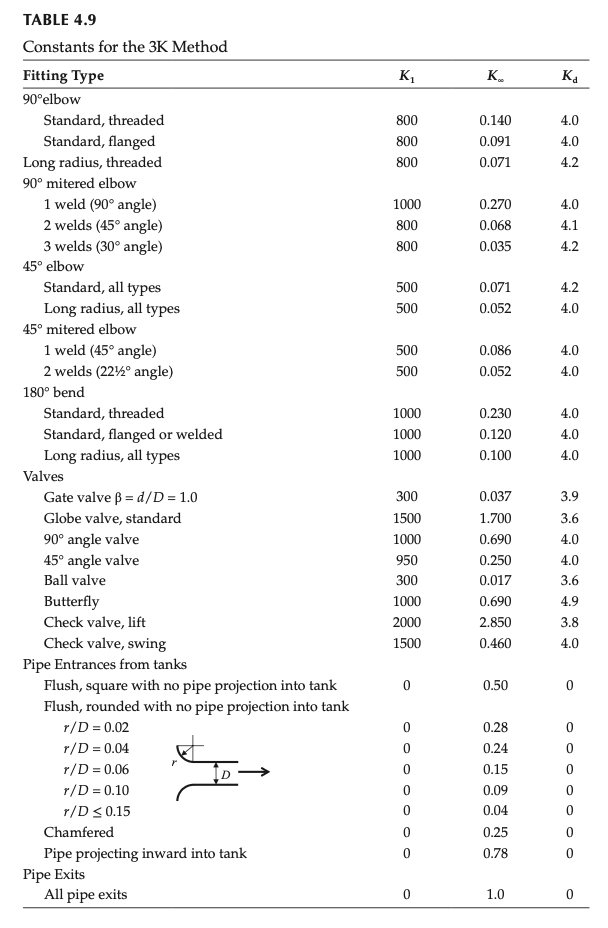

In [41]:
path_photo = os.path.join(os.getcwd(), 'fotos', 'piping_singularity_constants.png')  # Asegúrate de que 'photo.jpg' esté en el mismo directorio que este script
if os.path.exists(path_photo):
    img = Image.open(path_photo)
    display(img)  # Muestra la imagen en Jupyter
else:    
    print(f"No se encontró la imagen en la ruta: {path_photo}")

In [42]:
class PerdidaCarga:

    def __init__(self, Q, D_in, D_nominal, L, rho, mu, roughness):

        '''Recibe:
        Q: Caudal volumétrico (m³/s)
        D_in: Diámetro interno de la tubería (m)
        D_nominal: Diámetro nominal de la tubería (inch)
        L: Longitud de la tubería (m)
        rho: Densidad del fluido (kg/m³)
        mu: Viscosidad dinámica del fluido (Pa·s)
        roughness: Rugosidad absoluta de la tubería (m)'''

        self.Q = Q
        self.D_in = D_in
        self.D_nominal = D_nominal
        self.L = L
        self.rho = rho
        self.mu = mu
        self.roughness = roughness
        self.k_singularidad = 0

    def coeficientes_metodo_K3(self):
        self.fitting_constants_3k = {
            "90° elbow, standard, threaded": [800, 0.140, 4.0],
            "90° elbow, standard, flanged": [800, 0.091, 4.0],
            "90° elbow, long radius, threaded": [800, 0.071, 4.2],
            "90° mitered elbow, 1 weld (90° angle)": [1000, 0.270, 4.0],
            "90° mitered elbow, 2 welds (45° angle)": [800, 0.068, 4.1],
            "90° mitered elbow, 3 welds (30° angle)": [800, 0.035, 4.2],
            "45° elbow, standard, all types": [500, 0.071, 4.2],
            "45° elbow, long radius, all types": [500, 0.052, 4.0],
            "45° mitered elbow, 1 weld (45° angle)": [500, 0.086, 4.0],
            "45° mitered elbow, 2 welds (22½° angle)": [500, 0.052, 4.0],
            "180° bend, standard, threaded": [1000, 0.230, 4.0],
            "180° bend, standard, flanged or welded": [1000, 0.120, 4.0],
            "180° bend, long radius, all types": [1000, 0.100, 4.0],
            "Valve, gate β = d/D = 1.0": [300, 0.037, 3.9],
            "Valve, globe, standard": [1500, 1.700, 3.6],
            "Valve, 90° angle": [1000, 0.690, 4.0],
            "Valve, 45° angle": [950, 0.250, 4.0],
            "Valve, ball": [300, 0.017, 3.6],
            "Valve, butterfly": [1000, 0.690, 4.9],
            "Valve, check, lift": [2000, 2.850, 3.8],
            "Valve, check, swing": [1500, 0.460, 4.0],
            "Entrance, flush square (no pipe projection)": [0, 0.50, 0],
            "Entrance, flush rounded r/D = 0.02": [0, 0.28, 0],
            "Entrance, flush rounded r/D = 0.04": [0, 0.24, 0],
            "Entrance, flush rounded r/D = 0.06": [0, 0.15, 0],
            "Entrance, flush rounded r/D = 0.10": [0, 0.09, 0],
            "Entrance, flush rounded r/D ≤ 0.15": [0, 0.04, 0],
            "Entrance, chamfered": [0, 0.25, 0],
            "Entrance, pipe projecting inward": [0, 0.78, 0],
            "Exit, all pipe exits": [0, 1.00, 0],
        }


    def calcular_propiedades(self):
        self.A = np.pi * (self.D_in / 2) ** 2
        self.V = self.Q / self.A
        self.Re = (self.rho * self.V * self.D_in) / self.mu

    def calcular_factor_de_friccion(self):
        if self.Re < 2300:
            # For laminar flow, use the formula f = 64 / Re
            self.friction_factor = 64 / self.Re
        else:
            # Calculate friction factor using Swamee-Jain equation
            self.friction_factor = 0.25 / ( ( ( np.log10( ((self.roughness / self.D_in) / 3.7) + (5.74 / (self.Re ** 0.9))) ) ) ** 2)
        
    def agregar_perdida_singularidad(self, tipo_singularidad):
        if tipo_singularidad in self.fitting_constants_3k:
            K_1, K_inf, K_d = self.fitting_constants_3k[tipo_singularidad]
            self.k_singularidad += (K_1 / self.Re) + (K_inf * (1 + (K_d / ((self.D_nominal) ** 0.3))))

    def calcular_perdida_por_friccion(self):
        self.h_friccion = (self.friction_factor * self.L / self.D_in) * (self.rho * (self.V ** 2) / (2 * 9.81))

    def calcular_perdida_singularidad(self):
        self.h_singularidad = self.k_singularidad * (self.rho * (self.V ** 2) / (2 * 9.81))

    def calcular_perdida_total(self):
        self.h_total = self.h_friccion + self.h_singularidad

    

    